# Блок 3. Построение baseline модели

## Описание блока:
В данном блоке будет сформирована baseline модель для дальнейшего сравнения со всеми моделями. Подробное текстовое описания получившегося результата будет в  [Открыть тетрадку "Part 0"](Part%200.%20Research%20results.ipynb)

In [1]:
# импорт основных библиотек блока
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from all_functions.datasets_load import load_all_datasets
from all_functions.datasets_transfom import *


In [2]:
# фиксация сида на будущее
RANDOM_STATE = 654321

In [3]:
# загрузка датасетов
crypt_Ethereum, crypt_BTC, futures_Brent_LCOK5, \
futures_WTI_CLJ5, share_metal_jiangxi_copper, \
share_metal_baoshan_iron, share_oil_petrochina_hk, \
share_oil_equinor_oslo, spot_preciouse_metal_AG, spot_preciouse_metal_AU = load_all_datasets()

In [4]:
# трансформация датасетов
crypt_Ethereum = transform_data(crypt_Ethereum)
crypt_BTC = transform_data(crypt_BTC)

futures_WTI_CLJ5 = transform_data(futures_WTI_CLJ5)
futures_Brent_LCOK5 = transform_data(futures_Brent_LCOK5)

share_metal_jiangxi_copper  = transform_data(share_metal_jiangxi_copper)
share_metal_baoshan_iron  = transform_data(share_metal_baoshan_iron)

share_oil_petrochina_hk  = transform_data(share_oil_petrochina_hk)
share_oil_equinor_oslo  = transform_data(share_oil_equinor_oslo)

spot_preciouse_metal_AU  = transform_data(spot_preciouse_metal_AU)
spot_preciouse_metal_AG = transform_data(spot_preciouse_metal_AG)

## baseline

In [5]:
def split_data(data, train_ratio=0.85, val_ratio=0.1, test_ratio=0.05):
    
    '''функция по делению датасета на трейн, валидацию, тест'''

    n = len(data)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    train = data.iloc[:train_end]
    val = data.iloc[train_end:val_end]
    test = data.iloc[val_end:]

    return train, val, test
    

In [6]:
def return_x_y(data):

    x = data.drop(["Цена", "Откр.", "Макс.", "Мин."], axis = 1)
    y = data["Цена"]
    
    return x, y

In [7]:
def create_baseline(data, name):
    '''Функция по построению baseline моделей'''
    
    line_length = 150
    print('-' * line_length)
    print(f'Baseline датасета: {name}'.center(line_length))
    print('-' * line_length)

    # 1. Разделение сырых данных
    train_raw, valid_raw, test_raw = split_data(data)
    
    # 2. Построение фичей без утечек:
    tail_len = 30  # максимум лагов/скользящих окон
    
    # train
    train = upgrade_dataset(train_raw, mode="train")
    
    # valid с прокинутым хвостом
    valid_with_tail = pd.concat([train_raw.tail(tail_len), valid_raw])
    # valid_with_tail.to_csv("valid_with_tail.csv", index=True)
    valid_with_tail = upgrade_dataset(valid_with_tail, mode="valid")
    # обрезаем хвост
    valid = valid_with_tail.loc[valid_raw.index]
    
    # 3. Разделение на X и y
    X_train, y_train = return_x_y(train)
    X_valid, y_valid = return_x_y(valid)
    
    # 4. Обучение модели
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # 5. Предсказание
    y_pred = model.predict(X_valid)
    
    # 6. Оценка RMSE
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    print(f"RMSE на валидации: {rmse:.4f}")
    
    # 7. График
    plt.figure(figsize=(10, 5))
    plt.plot(y_valid.index, y_valid, label="Факт", color='blue')
    plt.plot(y_valid.index, y_pred, label="Прогноз", color='orange')
    plt.title("Линейная регрессия: прогноз и факт")
    plt.xlabel("Дата")
    plt.ylabel("Цена")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


------------------------------------------------------------------------------------------------------------------------------------------------------
                                                          Baseline датасета: crypt_Ethereum                                                           
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 303.2578


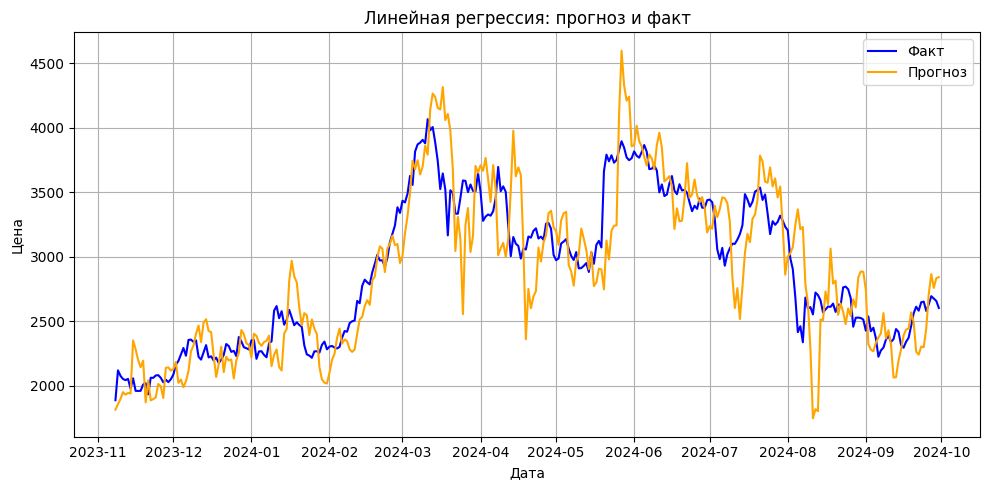

In [8]:
create_baseline(crypt_Ethereum, 'crypt_Ethereum')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                             Baseline датасета: crypt_BTC                                                             
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 5265.5555


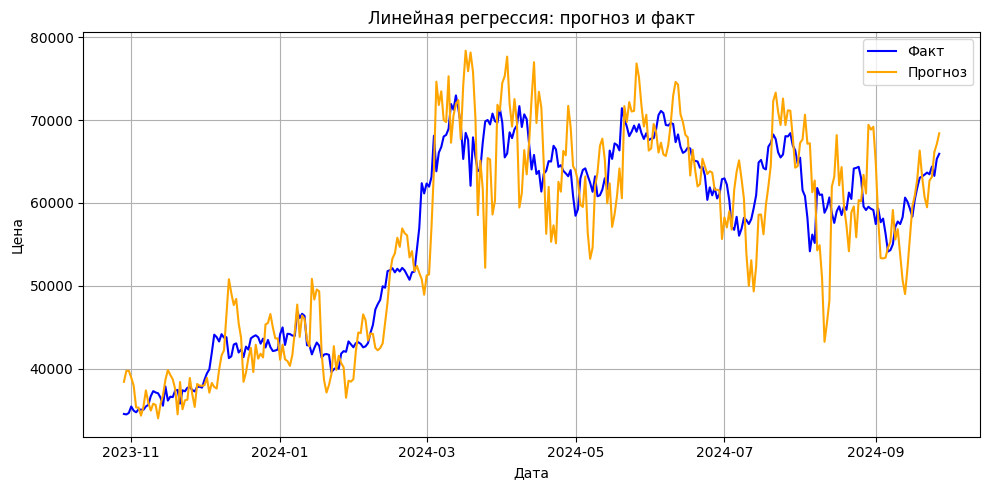

In [9]:
create_baseline(crypt_BTC, 'crypt_BTC')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                         Baseline датасета: futures_WTI_CLJ5                                                          
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 3.2246


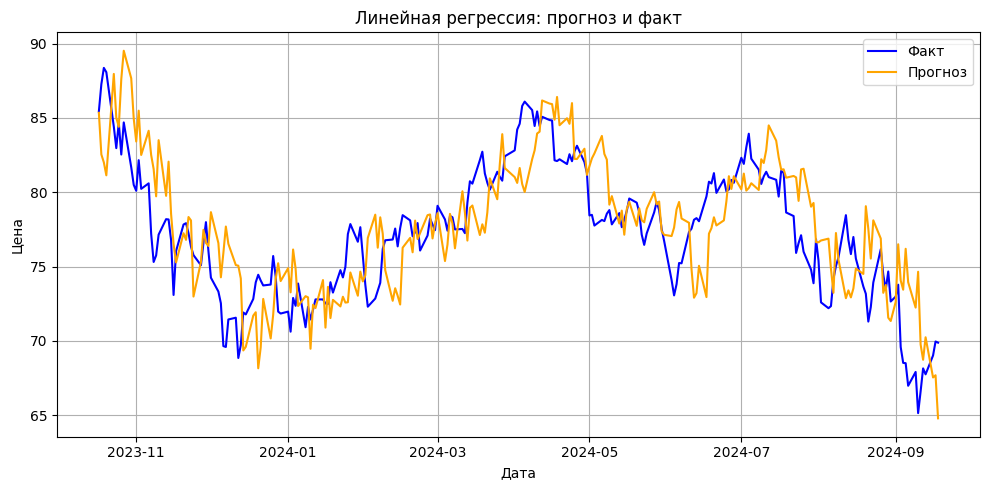

In [10]:
create_baseline(futures_WTI_CLJ5, 'futures_WTI_CLJ5')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                        Baseline датасета: futures_Brent_LCOK5                                                        
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 3.5650


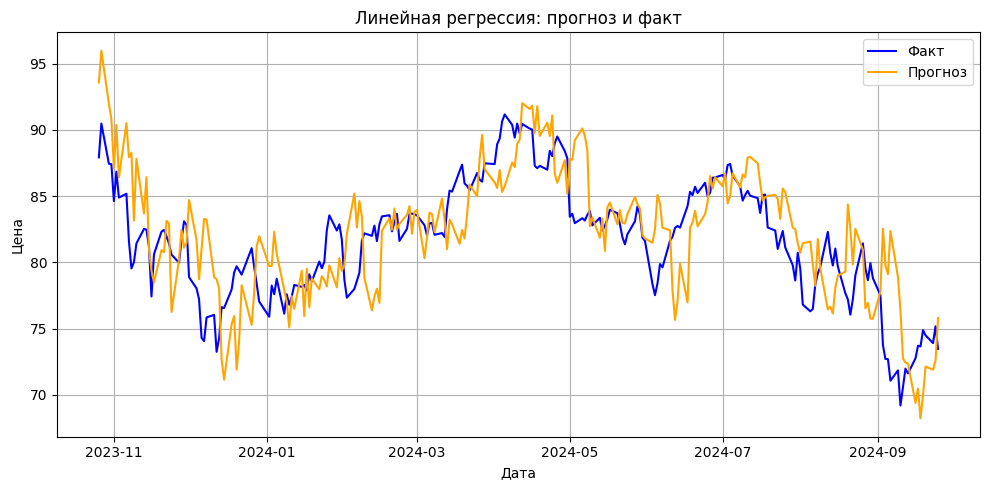

In [11]:
create_baseline(futures_Brent_LCOK5, 'futures_Brent_LCOK5')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                    Baseline датасета: share_metal_jiangxi_copper                                                     
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 0.9927


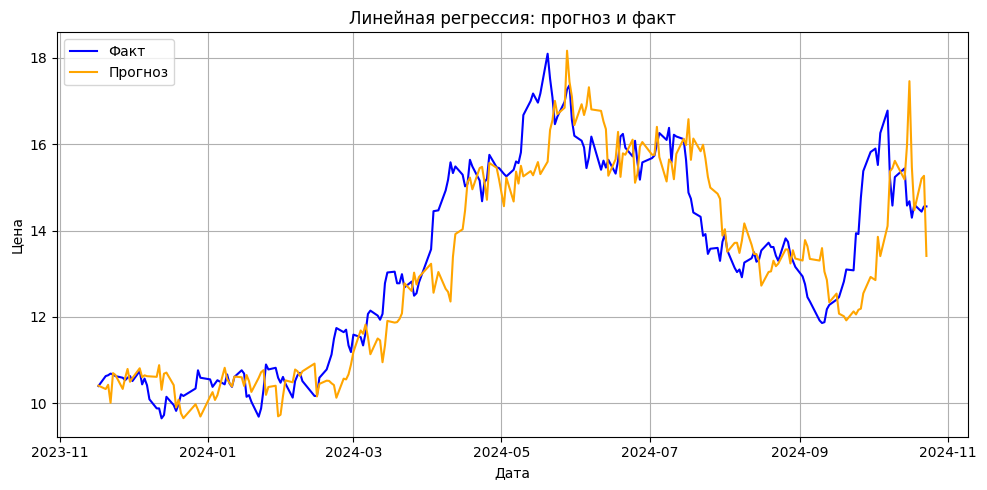

In [12]:
create_baseline(share_metal_jiangxi_copper, 'share_metal_jiangxi_copper')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                     Baseline датасета: share_metal_baoshan_iron                                                      
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 0.2973


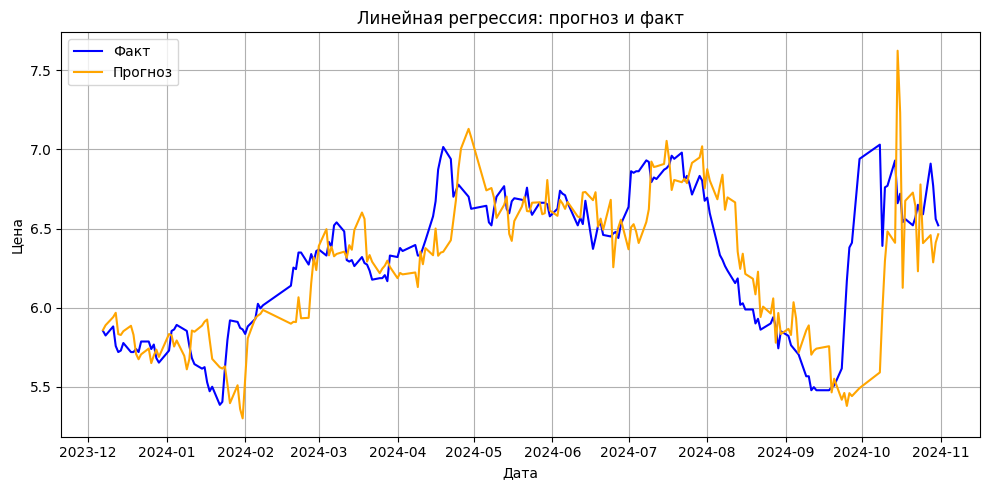

In [13]:
create_baseline(share_metal_baoshan_iron, 'share_metal_baoshan_iron')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                      Baseline датасета: share_oil_petrochina_hk                                                      
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 0.4224


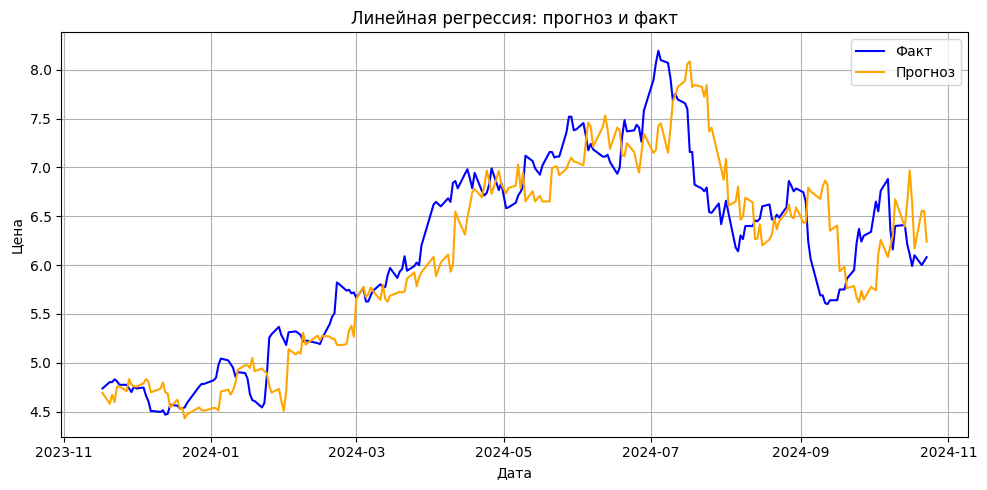

In [14]:
create_baseline(share_oil_petrochina_hk, 'share_oil_petrochina_hk')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                      Baseline датасета: share_oil_equinor_oslo                                                       
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 10.2241


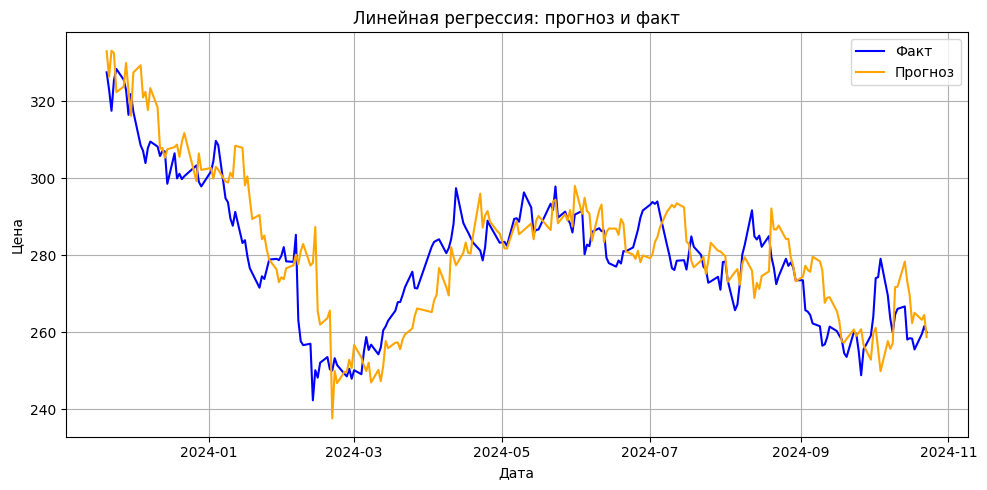

In [15]:
create_baseline(share_oil_equinor_oslo, 'share_oil_equinor_oslo')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                      Baseline датасета: spot_preciouse_metal_AU                                                      
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 60.0028


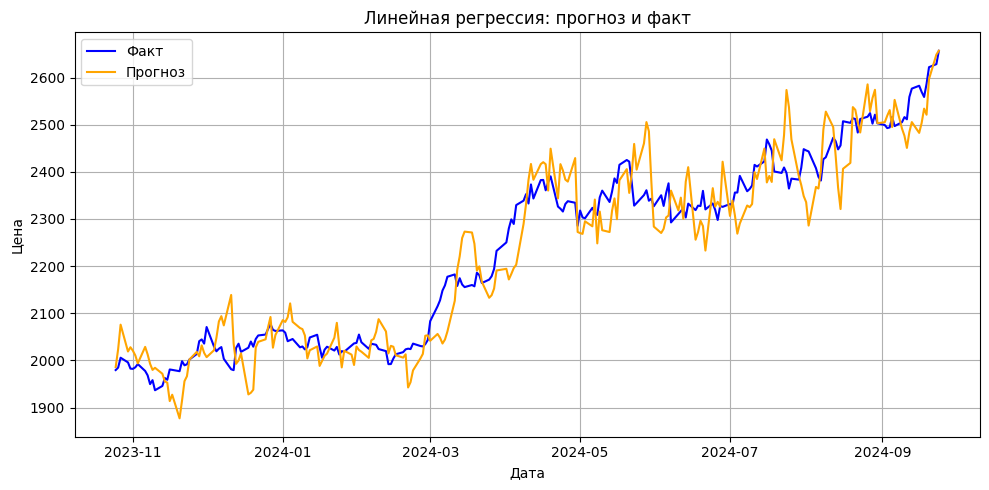

In [16]:
create_baseline(spot_preciouse_metal_AU, 'spot_preciouse_metal_AU')

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                      Baseline датасета: spot_preciouse_metal_AG                                                      
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 1.5833


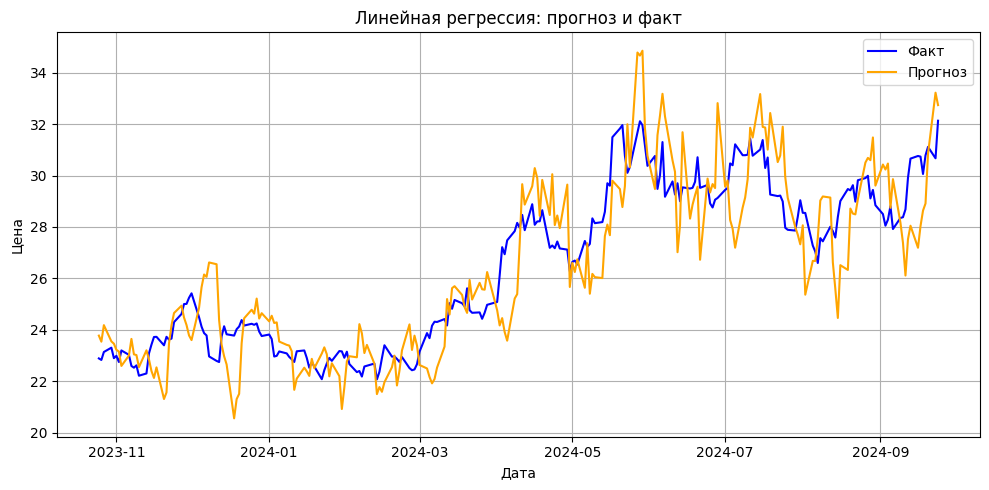

In [17]:
create_baseline(spot_preciouse_metal_AG, 'spot_preciouse_metal_AG')